In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

large_data_dir = gf_utils.large_data_dir

In [2]:
gf_dir = large_data_dir + 'gf_CL3_GenoType_Beta_HB/'
adata_path = large_data_dir + 'CL3_GenoType_Beta_HB_3plex.h5ad'

In [3]:
genotyping_mode = 'single_probe'
betaine_condition = 'betaine'

1992947 UMIs found
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 1990325 UMIs remaining (99.87%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 1757582 UMIs remaining (88.19%)
3582729 UMIs found
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 3579817 UMIs remaining (99.92%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 2929289 UMIs remaining (81.76%)
3112654 UMIs found
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 3109622 UMIs remaining (99.90%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 2531827 UMIs remaining (81.34%)
7218698  UMIs before filtering for read threshold
6412557  UMIs remaining after filtering for read threshold: 5


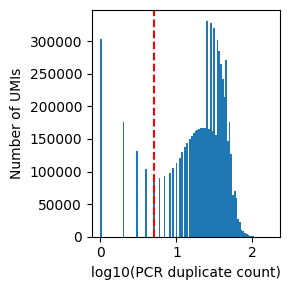

In [4]:
all_probe_reads = pd.DataFrame()
for probe_barcode in ['1','2','3']:
    manifest = gf_utils.get_manifest(gf_dir + 'BC' + probe_barcode + '_giftwrap/')
    manifest['name'] = manifest['name'].str.replace('_1','').str.replace('_0','')
    original_probes = pd.read_csv('../data/flex_genotyping_probes_set' + probe_barcode + '.csv')
    manifest = manifest.merge(original_probes[['lhs_probe','rhs_probe','type']], on = ['lhs_probe','rhs_probe'],how='outer')
    manifest.loc[manifest['type'].isna(),'type'] = 'alt' ## these are probes that should not actually be present (e.g. wildtype probe where only mutated probe was included)
    manifest.index = manifest['index']
    manifest = manifest.sort_index()
    manifest.loc[~manifest['name'].str.contains('c.'),'name'] = manifest.loc[~manifest['name'].str.contains('c.'),'name'] + ' 0bp' ## annotate non-variant probes as 0bp
    ## annotate if variant is on lhs or rhs
    for probe_side, col in [('lhs_probe', 'rhs'), ('rhs_probe', 'lhs')]:
        counts = manifest.loc[manifest['type'] == '0bp_genotyping'].groupby(probe_side).size()
        with_two = counts[counts == 2].index
        manifest.loc[manifest[probe_side].isin(with_two), 'variant'] = col

    probe_reads = gf_utils.get_input_probe_reads(gf_dir + 'BC' + probe_barcode + '_giftwrap/', read_threshold=0, min_percent_supporting=0.9, adata_path=adata_path)
    probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name','type','gapfill_start','variant']], left_on='probe_idx',right_index=True, how='left')

    all_probe_reads = pd.concat([all_probe_reads, probe_reads])

print(len(all_probe_reads), ' UMIs before filtering for read threshold')

read_threshold = 5
gf_utils.plot_reads_per_umi(probe_reads=all_probe_reads, read_threshold=read_threshold)

probe_reads = all_probe_reads.loc[all_probe_reads['pcr_duplicate_count'] > read_threshold].copy()
del all_probe_reads

print(len(probe_reads), ' UMIs remaining after filtering for read threshold:', read_threshold)


In [5]:
adata = gf_utils.read_adata(adata_path)


In [6]:
predicted_genotypes = pd.read_csv('../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv',sep=',')
predicted_genotypes.loc[predicted_genotypes['name'] == 'KRAS c.35G>*','name'] = 'KRAS c.34G>T'
predicted_genotypes = predicted_genotypes.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
predicted_genotypes = predicted_genotypes.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})

predicted_genotypes.loc['BCR-ABL','K562'] = 'mutated' ### fix here because we will not consider ref probe so BCR-ABL might as well be homozygous mutated

predicted_genotypes = predicted_genotypes.dropna()
probe_reads = probe_reads.merge(predicted_genotypes.reset_index().melt(id_vars='name', var_name='cell_type', value_name='genotype'), on = ['name','cell_type'], how='left')


In [7]:
### add allele calls to probe_reads

probe_reads['allele_call'] = np.select(
    [
        probe_reads['type'] == 'gapfill',
        probe_reads['type'] == '0bp_genotyping',
        probe_reads['type'] == 'wt',
        probe_reads['type'] == 'mutated'
    ],
    [
        np.where(
            probe_reads['gapfill'] == probe_reads['gapfill_from_transcriptome'], 'ref',
            np.where(probe_reads['gapfill'] == probe_reads['gap_probe_sequence'], 'alt', None)
        ),
        np.where(
            probe_reads['gapfill_start'].notna(), 'ref', 'alt' ### for dual probes assign ref if gapfill_start is not null (then probes were found in wt transcriptome)
        ),
        'ref',
        'alt'
    ],
    default=None
)


In [8]:
# Calculate the proportion of 'ref' allele calls among wt genotypes for each probe (name)

if genotyping_mode == 'single_probe':
    wt_allele_calls = probe_reads.loc[
        (probe_reads['type'] == 'wt') &
        (probe_reads['genotype'] == 'wt') &
        (probe_reads['allele_call'].isin(['ref', 'alt']))
    ]
else:
    wt_allele_calls = probe_reads.loc[
        (probe_reads['type'] == genotyping_mode) &
        (probe_reads['genotype'] == 'wt') &
        (probe_reads['allele_call'].isin(['ref', 'alt']))
    ]

p_ref_given_wt = wt_allele_calls.groupby('name')['allele_call'].apply(lambda x: (x == 'ref').mean())


# Calculate the proportion of 'alt' allele calls among mutated genotypes for each probe (name)

if genotyping_mode == 'single_probe':
    mutated_allele_calls = probe_reads.loc[
        (probe_reads['type'] == 'mutated') &
        (probe_reads['genotype'] == 'mutated') &
        (probe_reads['allele_call'].isin(['ref', 'alt']))
    ]
else:
    mutated_allele_calls = probe_reads.loc[
        (probe_reads['type'] == genotyping_mode) &
        (probe_reads['genotype'] == 'mutated') &
        (probe_reads['allele_call'].isin(['ref', 'alt']))
    ]

p_alt_given_mutated = mutated_allele_calls.groupby('name')['allele_call'].apply(lambda x: (x == 'alt').mean())

p_ref_given_wt.median(), p_alt_given_mutated.median()

(1.0, 1.0)

In [9]:
probe_counts = probe_reads.loc[
    (probe_reads['type'].isin(['wt','mutated'])) &
    (probe_reads['genotype'].isin(['wt','mutated'])) &
    (probe_reads['allele_call'].isin(['ref', 'alt']))
][['name','genotype','allele_call']].value_counts().reset_index()

probe_counts['correct'] = np.where(
    (probe_counts['genotype'] == 'wt') & (probe_counts['allele_call'] == 'ref'), True, 
    np.where(
        (probe_counts['genotype'] == 'mutated') & (probe_counts['allele_call'] == 'alt'), True,
        False
    )
)

probe_counts.to_csv('../output/single_probe_3plex_counts.csv')
